# Model Training for MLChem Tools 

## 1) Import necessary libraries 

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_curve, auc, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns


try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

## 2) load + cleaning data + EDA

In [2]:
DATA_PATH = "Dataset.xlsx"  
RANDOM_STATE = 42

In [3]:
# a) load data
df = pd.read_excel(DATA_PATH)
before = len(df)
df = df.dropna(subset=["Primary Method", "property"]).reset_index(drop=True)
print(f"Load: {before} rows -> {len(df)} after dropping missing values")

Load: 338 rows -> 337 after dropping missing values


In [4]:
# b) checking if there is any duplicated
n_dup_papers = df["Paper"].duplicated().sum()
print(f"Paper exist >1x (because multi-property, not error): {n_dup_papers} rows "
      f"-> split must group-aware per Paper\n")

Paper exist >1x (because multi-property, not error): 9 rows -> split must group-aware per Paper



In [5]:
# c) TARGET LABEL CANONICALIZATION & CLEANING
# ------------------------------------------------------------------
# This function standardizes heterogenous text inputs in the 'Primary Method' column 
# into three distinct, well-defined categorical classes: COSMO-RS, DFT, and MD.
# It uses keyword mapping (e.g., merging variants like 'AIMD' or 'NEMD' into 'MD')
# to reduce labeling noise and ensure uniform targets for the machine learning model.

def canonicalize_method(raw: str) -> str:
    s = str(raw).lower()
    if "cosmo" in s:
        return "COSMO-RS"
    if "dft" in s or "cdft" in s or "first-principles" in s or "negf" in s:
        return "DFT"
    if ("molecular dynamics" in s or re.search(r"\bmd\b", s) or "aimd" in s
            or "nemd" in s or "smd" in s or "fpmd" in s or "reaxff" in s):
        return "MD"
    return "Other"

# Apply the text mapping rule across the dataset
df["method_final"] = df["Primary Method"].apply(canonicalize_method)

# Filter out irrelevant or generic classes ('Other') to keep the study focused on the 3 core methods
df = df[df["method_final"] != "Other"].reset_index(drop=True)

print("Target Distribution (3 Classes):")
print(df["method_final"].value_counts())

Target Distribution (3 Classes):
method_final
DFT         143
MD          103
COSMO-RS     77
Name: count, dtype: int64


In [6]:
# Baseline Majority-Class Accuracy (Zero-R Benchmark)
# Condition where a dummy system guesses 100% of the data as the most frequent class ('DFT').
# Used as the absolute minimum performance threshold; any useful ML model 
# must significantly outperform this baseline to prove it has learned meaningful patterns.

print(f"Baseline majority-class accuracy: {(df['method_final']=='DFT').mean():.1%}\n")

Baseline majority-class accuracy: 44.3%



In [7]:
# d) META-FEATURE TAXONOMY MAPPING (10 HIGH-LEVEL CATEGORIES)
# ------------------------------------------------------------------
# This mapping consolidates diverse and fine-grained raw strings from 'property' 
# and 'sub_property' into 10 scientifically standardized domains.
# Note: This meta-feature is intended purely for EDA visualization and 
# interactive Dropdown UI selection, rather than a direct training feature for ML.

TAXONOMY = {
    # 1. Thermodynamic Properties
    "Thermodynamic Properties": ["gibbs free energy","enthalpy","entropy","heat capacity","solubility",
        "phase equilibri","henry's constant","henrys constant","activity coefficient",
        "fugacity","chemical potential","free energy of mixing","solvation free energy"],

    # 2. Kinetic & Reaction Properties
    "Kinetic & Reaction Properties": ["reaction mechanism","activation energy","transition state",
        "reaction rate","reaction pathway","catalytic activity","bond breaking","bond formation",
        "decomposition mechanism","degradation mechanism","reaction kinetic"],

    # 3. Transport Properties
    "Transport Properties": ["diffusivity","diffusion","permeability","viscosity","thermal conductivity",
        "mass transfer coefficient","ionic conductivity","ion transport"],

    # 4. Structural & Electronic Properties
    "Structural & Electronic Properties": ["molecular geometry","bond length","bond angle",
        "electronic structure","band gap","density of states","charge distribution","surface structure",
        "crystal structure","lattice parameter","amorphous structure","structural stability",
        "structural assignment","regioisomer"],

   # 5. Molecular Interaction Properties
    "Molecular Interaction Properties": ["binding energy","adsorption energy","adsorption mechanism",
        "adsorption behavior","intermolecular force","hydrogen bond","van der waals",
        "electrostatic interaction","solute-solvent","solute–solvent","host-guest","host–guest",
        "non-covalent","force field parameterization","drug-nanocarrier","drug–nanocarrier",
        "drug-micelle","drug–micelle","metal-ligand","metal–ligand","interfacial adhesion",
        "protein-nanoparticle","protein–nanoparticle","protein-metal","protein–metal"],

    # 6. Adsorption & Porous Media Properties
    "Adsorption & Porous Media Properties": ["adsorption isotherm","adsorption capacity",
        "adsorption selectivity","competitive adsorption","pore filling","surface coverage",
        "gas adsorption","gas sensing"],

    # 7. Multicomponent & Process-Level Properties
    "Multicomponent & Process-Level Properties": ["mixture selectivity","phase behavior of mixtures",
        "process thermodynamics","scale-up","coupled transport","extraction","separation","screening"],

    # 8. Biomedical & Biochemical  Properties
    "Biomedical & Biochemical Properties": ["drug-protein","drug–protein","protein-ligand","protein–ligand",
        "conformational change","enzyme reaction mechanism","docking scoring","biomolecular stability",
        "molecular docking","protein extraction","biointerface"],

    # 9. Energy & Environmental Properties
    "Energy & Environmental Properties": ["gas separation selectivity","co2 absorption","co₂ absorption",
        "h2s removal","h₂s removal","membrane performance","electrochemical propert","battery material",
        "hydrogen storage","photocatalytic","catalytic","water desalination","salt rejection"],

    # 10. Optical & Spectroscopic Properties
    "Optical & Spectroscopic Properties": ["optical","nlo","nonlinear optical","photophysical",
        "dielectric relaxation","spectral fingerprint","vibrational","charge transfer","ict",
        "chiroptical","esipt","proton transfer","optical limiting","fluorescence","absorption spectr",
        "raman","infrared spectr","uv-vis"],
}

# Score-based keyword matching algorithm:
# Evaluates total token match density per category and assigns the dominant class.
# Default fallback is set to "Other" for unmatched texts.

def map_taxonomy(text: str) -> str:
    scores = {cat: sum(1 for kw in kws if kw in text) for cat, kws in TAXONOMY.items()}
    scores = {k: v for k, v in scores.items() if v > 0}
    return max(scores, key=scores.get) if scores else "Other"

# Concatenate granular domain features and extract the higher-level taxonomy
df["macro_property"] = (df["property"] + " " + df["sub_property"]).str.lower().apply(map_taxonomy)

print("macro_property distribution (10 categories + Other):")
print(df["macro_property"].value_counts())

# Check how many entries successfully matched our chemical engineering domain logic
print(f"    Coverage taxonomy: {(df['macro_property'] != 'Other').mean():.1%}\n")


macro_property distribution (10 categories + Other):
macro_property
Thermodynamic Properties                     66
Molecular Interaction Properties             46
Transport Properties                         46
Other                                        42
Structural & Electronic Properties           38
Optical & Spectroscopic Properties           32
Multicomponent & Process-Level Properties    18
Energy & Environmental Properties            14
Kinetic & Reaction Properties                 9
Biomedical & Biochemical Properties           7
Adsorption & Porous Media Properties          5
Name: count, dtype: int64
    Coverage taxonomy: 87.0%



### EDA

In [8]:
# Set publication-quality aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'figure.titlesize': 14
})

/var/folders/fh/3rw7ypm52s79sv5l1sp19zg00000gn/T/ipykernel_276/3049510744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(


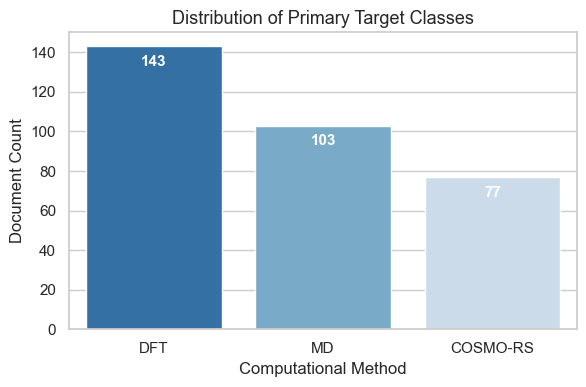

In [9]:
# ==================================================================
# EDA 1: Target Class Distribution (Computational Chemistry Methods)
# ==================================================================
plt.figure(figsize=(6, 4))
ax1 = sns.countplot(
    x="method_final", 
    data=df, 
    order=df["method_final"].value_counts().index, 
    palette="Blues_r"
)
plt.title("Distribution of Primary Target Classes")
plt.xlabel("Computational Method")
plt.ylabel("Document Count")

# Add value annotations on top of the bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                 (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_1_target_distribution.png", dpi=300)
plt.show()




/var/folders/fh/3rw7ypm52s79sv5l1sp19zg00000gn/T/ipykernel_276/730459471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(


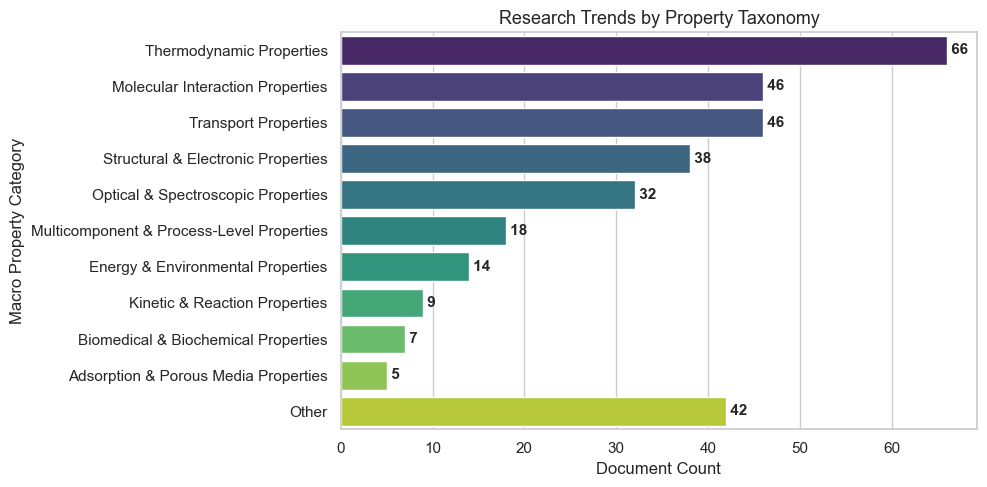

In [10]:
# ==================================================================
# EDA 2: Macro Property Taxonomy Distribution
# ==================================================================
plt.figure(figsize=(10, 5))
# Sort the property distribution so that 'Other' always stays at the bottom
property_counts = df["macro_property"].value_counts()
order_list = [idx for idx in property_counts.index if idx != 'Other'] + (['Other'] if 'Other' in property_counts else [])

ax2 = sns.countplot(
    y="macro_property", 
    data=df, 
    order=order_list, 
    palette="viridis"
)
plt.title("Research Trends by Property Taxonomy")
plt.xlabel("Document Count")
plt.ylabel("Macro Property Category")

# Add value annotations next to the horizontal bars
for p in ax2.patches:
    ax2.annotate(f' {int(p.get_width())}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_2_property_taxonomy.png", dpi=300)
plt.show()


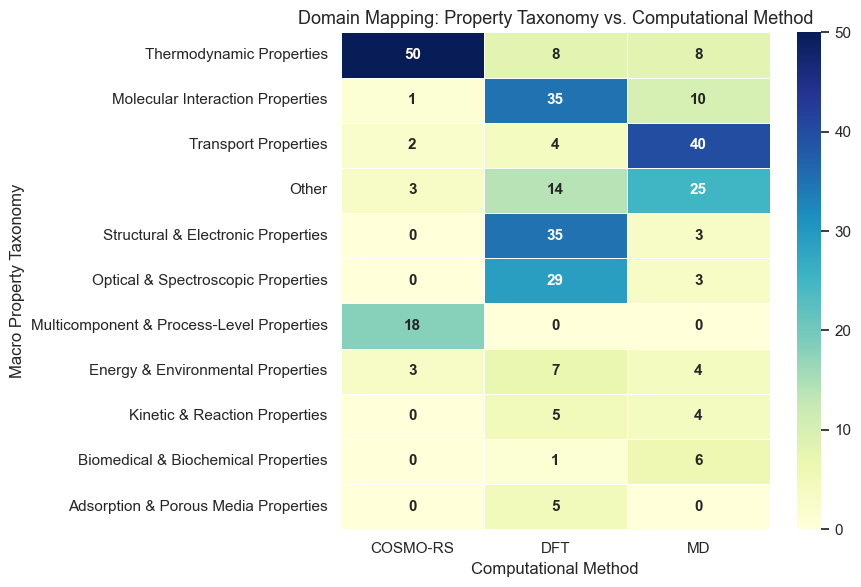

In [11]:
# ==================================================================
# EDA 3: Cross-Tabulation Matrix (Method vs. Property Heatmap)
# ==================================================================
# Generate a contingency table to analyze domain correlations
cross_tab = pd.crosstab(df["macro_property"], df["method_final"])
# Sort by the most frequent property domains overall
cross_tab = cross_tab.loc[cross_tab.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(9, 6))
sns.heatmap(
    cross_tab, 
    annot=True, 
    fmt="d", 
    cmap="YlGnBu", 
    cbar=True, 
    linewidths=.5,
    annot_kws={"weight": "bold"}
)
plt.title("Domain Mapping: Property Taxonomy vs. Computational Method")
plt.xlabel("Computational Method")
plt.ylabel("Macro Property Taxonomy")

plt.tight_layout()
plt.savefig("eda_3_cross_mapping_heatmap.png", dpi=300)
plt.show()

In [12]:
# ==================================================================
# EDA 4: Raw Feature Column Cardinality Check
# Purpose: Measures token unique variety to support Dropdown UI 
#          and taxonomy mapping architecture design decisions.
# ==================================================================
print("[4] EDA - Feature Column Cardinality Analysis:")
columns_to_check = ["property", "sub_property", "Application Domain", "System Type", "macro_property"]

for col in columns_to_check:
    # Handle missing values cleanly and standardize as string
    df[col] = df[col].fillna("").astype(str)
    unique_count = df[col].nunique()
    total_rows = len(df)
    print(f"    * {col:<20} : {unique_count:<4} unique values across {total_rows} rows")
print()

[4] EDA - Feature Column Cardinality Analysis:
    * property             : 134  unique values across 323 rows
    * sub_property         : 296  unique values across 323 rows
    * Application Domain   : 251  unique values across 323 rows
    * System Type          : 297  unique values across 323 rows
    * macro_property       : 11   unique values across 323 rows



## 3) Feature Engineering

In [16]:
# FEATURE ENGINEERING & TARGET ENCODING
# ==================================================================
# 1. Feature Construction: Concatenate granular raw text features into a single unified text corpus.
#    NOTE: 'macro_property' is INTENTIONALLY EXCLUDED from model training features.
#    The 10-class taxonomy is designed strictly for Dropdown UI filtering and EDA metadata.
#    Empirical tests verified that including 'macro_property' does not yield significant 
#    performance shifts; thus, it is kept separate to maintain design transparency 
#    ("the model learns strictly from pure raw literature text, taxonomy is purely for UI interface").

text_all = (df["property"] + " . " + df["sub_property"] + " . " +
            df["Application Domain"] + " . " + df["System Type"]).values

# 2. Target Label Encoding: Convert nominal text categories into structured numerical labels.
le = LabelEncoder()
y = le.fit_transform(df["method_final"])

# 3. Group Identity Extraction: Retain paper IDs to prevent data leakage during Stratified Group CV.
groups = df["Paper"].values

print(f"Feature Engineering Complete:")
print(f"    * Total constructed text rows : {len(text_all)}")
print(f"    * Encoded target classes      : {list(le.classes_)}\n")

Feature Engineering Complete:
    * Total constructed text rows : 323
    * Encoded target classes      : ['COSMO-RS', 'DFT', 'MD']



## 4) Data Splitting

In [17]:
# HELD-OUT TEST SET PARTITIONING (LEAK-PROOF DATA SPLITTING)
# ==================================================================
# Data partitioning is strictly executed at the RAW TEXT level.
# GroupShuffleSplit is utilized to ensure that all data rows originating from 
# the same publication ('Paper' groups) stay entirely within the same partition.
# This prevents data leakage, as the TF-IDF vectorizer remains completely blind 
# to the held-out test set until final evaluation.

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(text_all, y, groups=groups))

# Carving out the train and test partitions
text_train, text_test = text_all[train_idx], text_all[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"[6] Held-out Test Set Final Partitioning:")
print(f"    * Test Set size       : {len(test_idx)} rows ({len(test_idx)/len(df):.1%}) from {len(np.unique(groups[test_idx]))} unique papers")
print(f"    * Training Pool size  : {len(train_idx)} rows from {len(np.unique(groups_train))} unique papers")
print("    * Note: TF-IDF has NOT been fitted yet -> Zero data leakage guaranteed.\n")

[6] Held-out Test Set Final Partitioning:
    * Test Set size       : 50 rows (15.5%) from 48 unique papers
    * Training Pool size  : 273 rows from 266 unique papers
    * Note: TF-IDF has NOT been fitted yet -> Zero data leakage guaranteed.



## 5) Model Selection + training

In [18]:
# MODEL SELECTION VIA PIPELINE-BASED CROSS-VALIDATION
# ==================================================================
# Evaluation is conducted strictly within the training pool using a
# 5-Fold Stratified Group Cross-Validation strategy. By nesting the
# TF-IDF vectorizer inside a Pipeline, feature extraction parameters are
# re-fitted uniquely on each validation fold, ensuring zero data leakage.

def make_tfidf():
    return TfidfVectorizer(
        max_features=1500,
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
        stop_words="english"
    )

# Dictionary of baseline classifiers, model variants, and advanced ensemble configurations
model_defs = {
    "Multinomial Naive Bayes (Alpha 0.3)": MultinomialNB(alpha=0.3),

    "Complement NB (Alpha 0.1)": ComplementNB(alpha=0.1),
    "Complement NB (Alpha 0.3)": ComplementNB(alpha=0.3),
    "Complement NB (Alpha 0.5)": ComplementNB(alpha=0.5),

    # Logistic Regression with class imbalance handling
    "Logistic Regression (balanced)": LogisticRegression(
        max_iter=3000, class_weight="balanced", C=2.0
    ),

    # Standard Logistic Regression without class balancing
    "Logistic Regression (standard)": LogisticRegression(
        max_iter=3000, C=2.0
    ),

    # Soft-margin SVM calibrated to produce class probability estimates
    "Linear SVC (calibrated)": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", C=1.0), cv=3
    ),

    # Soft Voting Ensemble with a higher empirical weight assigned to Complement Naive Bayes
    "Ensemble Soft Voting": VotingClassifier(
        estimators=[
            ("nb", ComplementNB(alpha=0.3)),
            ("lr", LogisticRegression(max_iter=3000, class_weight="balanced", C=2.0)),
            ("svc", CalibratedClassifierCV(LinearSVC(class_weight="balanced"), cv=3)),
        ],
        voting="soft",
        weights=[1.5, 1, 1]
    )
}

if HAS_XGB:
    model_defs["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric="mlogloss", random_state=RANDOM_STATE
    )

# Preserves class distribution across folds while ensuring that documents
# from the same research paper remain within the same fold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("MODEL SELECTION (5-fold Stratified Group CV Execution):")
print("-" * 110)
print(f"{'Model Architecture':<38} | {'CV Acc':<7} | {'CV Prec':<7} | {'CV Rec':<7} | {'CV Macro F1':<15} | {'Train F1':<8} | {'Gap':<5}")
print("-" * 110)

cv_results = {}

for name, clf in model_defs.items():
    f1s, tr_f1s = [], []
    accs, precs, recs = [], [], []

    for tr, va in sgkf.split(text_train, y_train, groups=groups_train):
        pipe = Pipeline([("tfidf", make_tfidf()), ("clf", clf)])
        pipe.fit(text_train[tr], y_train[tr])

        y_pred_va = pipe.predict(text_train[va])
        y_pred_tr = pipe.predict(text_train[tr])

        # Compute additional evaluation metrics on the validation (held-out) fold
        accs.append(accuracy_score(y_train[va], y_pred_va))
        precs.append(precision_score(y_train[va], y_pred_va, average="macro", zero_division=0))
        recs.append(recall_score(y_train[va], y_pred_va, average="macro", zero_division=0))

        # Compute Macro F1 scores to assess generalization performance and overfitting
        f1s.append(f1_score(y_train[va], y_pred_va, average="macro", zero_division=0))
        tr_f1s.append(f1_score(y_train[tr], y_pred_tr, average="macro", zero_division=0))

    mean_val, std_val, mean_tr = np.mean(f1s), np.std(f1s), np.mean(tr_f1s)
    mean_acc = np.mean(accs)
    mean_prec = np.mean(precs)
    mean_rec = np.mean(recs)

    gap = mean_tr - mean_val
    cv_results[name] = (mean_val, std_val, mean_tr)

    # Print a formatted comparison row for each model
    print(
        f"* {name:<36} | {mean_acc:.3f}  | {mean_prec:.3f}   | "
        f"{mean_rec:.3f}   | {mean_val:.3f} ± {std_val:.3f} | "
        f"{mean_tr:.3f}  | {gap:.3f}"
    )

MODEL SELECTION (5-fold Stratified Group CV Execution):
--------------------------------------------------------------------------------------------------------------
Model Architecture                     | CV Acc  | CV Prec | CV Rec  | CV Macro F1     | Train F1 | Gap  
--------------------------------------------------------------------------------------------------------------
* Multinomial Naive Bayes (Alpha 0.3)  | 0.868  | 0.870   | 0.876   | 0.867 ± 0.042 | 0.972  | 0.105
* Complement NB (Alpha 0.1)            | 0.864  | 0.859   | 0.877   | 0.861 ± 0.032 | 0.974  | 0.113
* Complement NB (Alpha 0.3)            | 0.864  | 0.862   | 0.880   | 0.862 ± 0.027 | 0.971  | 0.109
* Complement NB (Alpha 0.5)            | 0.868  | 0.868   | 0.881   | 0.865 ± 0.032 | 0.970  | 0.104
* Logistic Regression (balanced)       | 0.846  | 0.854   | 0.857   | 0.851 ± 0.036 | 0.990  | 0.139
* Logistic Regression (standard)       | 0.864  | 0.882   | 0.869   | 0.868 ± 0.053 | 0.989  | 0.121
* Linear S

In [19]:
# MULTI-CRITERIA MODEL SELECTION (PERFORMANCE VS. GENERALIZATION GAP)
# ==================================================================
# Rather than blindly selecting the absolute highest validation score, 
# this rigorous audit framework filters models within a 0.5% tolerance margin 
# of the top performer. From this elite tier, the final model is selected 
# based on the minimum generalization gap (Train F1 - Validation F1) 
# to guarantee robust structural stability and mitigate overfitting risks.

MARGIN_TOLERANCE = 0.005

# Extract the absolute peak validation macro F1 achieved
max_cv_f1 = max(cv_results.values(), key=lambda x: x[0])[0]

top_tier_models = {}
print("\n[Model Selection Audit] Reviewing Top-Tier Candidates:")
for name, metrics in cv_results.items():
    cv_f1, _, train_f1 = metrics
    gap = train_f1 - cv_f1
    
    # Check if the model's performance falls within the allowable statistical margin
    if (max_cv_f1 - cv_f1) <= MARGIN_TOLERANCE:
        top_tier_models[name] = gap
        print(f"   -> {name:<38} added to short-list (Generalization Gap: {gap:.3f})")

# Final Decision: Select the short-listed candidate with the MINIMUM generalization gap
best_name = min(top_tier_models, key=top_tier_models.get)

print(f"\n>>> AUTOMATED PIPELINE DECISION:")
print(f"    While the peak absolute CV Macro F1 was {max_cv_f1:.3f}, the model selected")
print(f"    The Best Model is: '{best_name}'")
print(f"    due to superior stability and a minimum generalization gap of ({top_tier_models[best_name]:.3f})!\n")


[Model Selection Audit] Reviewing Top-Tier Candidates:
   -> Multinomial Naive Bayes (Alpha 0.3)    added to short-list (Generalization Gap: 0.105)
   -> Complement NB (Alpha 0.5)              added to short-list (Generalization Gap: 0.104)
   -> Logistic Regression (standard)         added to short-list (Generalization Gap: 0.121)
   -> Ensemble Soft Voting                   added to short-list (Generalization Gap: 0.119)

>>> AUTOMATED PIPELINE DECISION:
    While the peak absolute CV Macro F1 was 0.868, the model selected
    The Best Model is: 'Complement NB (Alpha 0.5)'
    due to superior stability and a minimum generalization gap of (0.104)!



# 6) Evaluation and Visualization

In [20]:
# FINAL RETRAINING & EVALUATION ON HELD-OUT TEST SET
# ==================================================================
# The optimally audited architecture is re-trained on the ENTIRE training pool.
# The TF-IDF parameters are fitted strictly on 'text_train'. The blind 'text_test'
# partition is purely transformed—guaranteeing 100% leak-proof inference.

best_pipe = Pipeline([("tfidf", make_tfidf()), ("clf", model_defs[best_name])])
best_pipe.fit(text_train, y_train)          # TF-IDF fits ONLY on the training pool
y_pred_test = best_pipe.predict(text_test)  # Inference via pure transform only

print("=" * 65)
print("[FINAL EVALUATION ON BLIND HELD-OUT TEST SET")
print("=" * 65)
print(f"Final Chosen Model : {best_name}")
print(f"Test Accuracy      : {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Test Macro F1      : {f1_score(y_test, y_pred_test, average='macro', zero_division=0):.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_, zero_division=0))


[FINAL EVALUATION ON BLIND HELD-OUT TEST SET
Final Chosen Model : Complement NB (Alpha 0.5)
Test Accuracy      : 0.880
Test Macro F1      : 0.877

Classification Report:
              precision    recall  f1-score   support

    COSMO-RS       0.80      0.92      0.86        13
         DFT       1.00      0.82      0.90        22
          MD       0.82      0.93      0.88        15

    accuracy                           0.88        50
   macro avg       0.87      0.89      0.88        50
weighted avg       0.90      0.88      0.88        50



--- 1. Underlying Confusion Matrix Dataset (with Totals) ---
                 COSMO-RS  DFT  MD  Total Actual
COSMO-RS               12    0   1            13
DFT                     2   18   2            22
MD                      1    0  14            15
Total Predicted        15   18  17            50


--- 2. One-vs-Rest Underlying Values Breakdown ---
                      True Positive (TP)  True Negative (TN)  \
Computational Method                                           
COSMO-RS                              12                  34   
DFT                                   18                  28   
MD                                    14                  32   

                      False Positive (FP)  False Negative (FN)  
Computational Method                                            
COSMO-RS                                3                    1  
DFT                                     0                    4  
MD                                      3                   

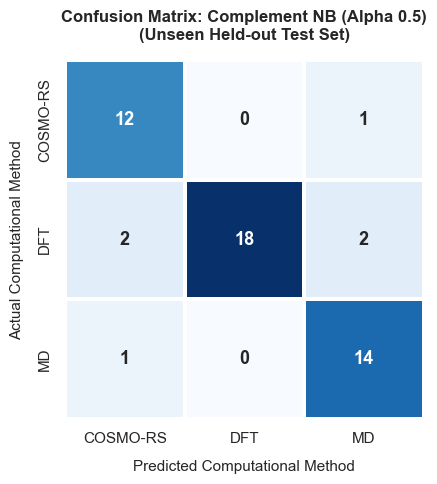

In [25]:
# ==================================================================
# 1. COMPUTE RAW CONFUSION MATRIX & EXTRACT LABELS
# ==================================================================
cm_raw = confusion_matrix(y_test, y_pred_test)
classes = le.classes_

# ==================================================================
# 2. GENERATE TEXT-BASED DATASETS FOR REVIEWER VERIFICATION
# ==================================================================
# Construct the standard 3x3 DataFrame
cm_df = pd.DataFrame(cm_raw, index=classes, columns=classes)

# Create a copy specifically to append row and column totals for text display
cm_df_totals = cm_df.copy()
cm_df_totals["Total Actual"] = cm_df_totals.sum(axis=1)
cm_df_totals.loc["Total Predicted"] = cm_df_totals.sum(axis=0)

print("--- 1. Underlying Confusion Matrix Dataset (with Totals) ---")
print(cm_df_totals)
print("\n" + "=" * 60 + "\n")

# Calculate granular TP, TN, FP, FN metrics using a One-vs-Rest (OvR) approach
ovr_data = []
total_samples = np.sum(cm_raw)

for i, class_name in enumerate(classes):
    tp = cm_raw[i, i]
    fp = np.sum(cm_raw[:, i]) - tp
    fn = np.sum(cm_raw[i, :]) - tp
    tn = total_samples - (tp + fp + fn)

    ovr_data.append(
        {
            "Computational Method": class_name,
            "True Positive (TP)": tp,
            "True Negative (TN)": tn,
            "False Positive (FP)": fp,
            "False Negative (FN)": fn,
        }
    )

# Convert the structured OvR metrics list into a clean DataFrame
ovr_df = pd.DataFrame(ovr_data)
ovr_df.set_index("Computational Method", inplace=True)

print("--- 2. One-vs-Rest Underlying Values Breakdown ---")
print(ovr_df)
print("\n" + "=" * 60 + "\n")

# ==================================================================
# 3. DATA VISUALIZATION (CONFUSION MATRIX HEATMAP)
# ==================================================================
# Setup figures and clear standard grid lines for a clean matrix interface
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

# Plot the clean 3x3 matrix (excluding totals to maintain correct color scaling)
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,  # Removed colorbar as raw counts are small and fully visible
    square=True,
    linewidths=1.5,
    linecolor="white",
    annot_kws={"size": 13, "weight": "bold"},
)

# Render publication-standard labels and titles
plt.title(
    "Confusion Matrix: Complement NB (Alpha 0.5)\n(Unseen Held-out Test Set)",
    fontsize=12,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Predicted Computational Method", fontsize=11, labelpad=10)
plt.ylabel("Actual Computational Method", fontsize=11, labelpad=10)

# Adjust layout boundaries and render the plot
plt.tight_layout()
plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


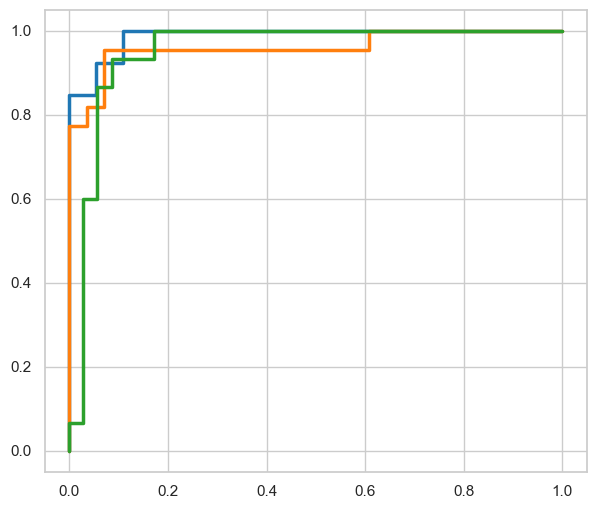

In [41]:
# 1. Binarize the y_test labels into a binary matrix (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # 0: COSMO-RS, 1: DFT, 2: MD
n_classes = y_test_bin.shape[1]

# 2. Obtain prediction probabilities (instead of predicted class labels)
# Complement Naive Bayes supports predict_proba()
y_score = best_pipe.predict_proba(text_test)

# 3. Set up the plot
plt.figure(figsize=(7, 6))
sns.set_theme(style="whitegrid")  # Apply a subtle grid for a more professional appearance

# Aesthetic color palette suitable for publication
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
class_names = le.classes_  # Automatically retrieves ['COSMO-RS', 'DFT', 'MD']

# 4. Compute the ROC curve and AUC for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        color=colors[i],
        lw=2.5,
        label=f"ROC of {class_names[i]} (AUC = {roc_auc:.3f})"
    )

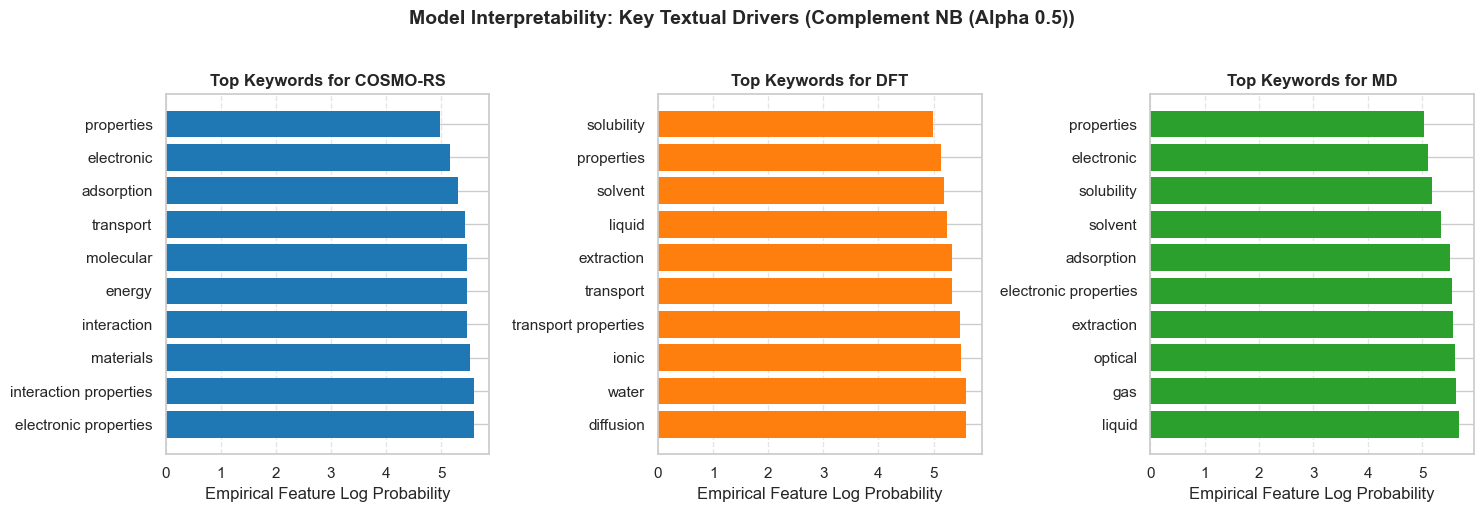

In [42]:
# Extract the TF-IDF vectorizer and trained classifier from the best-performing pipeline
tfidf_step = best_pipe.named_steps["tfidf"]
clf_step = best_pipe.named_steps["clf"]

# Retrieve the complete TF-IDF feature vocabulary
feature_names = np.array(tfidf_step.get_feature_names_out())
class_names = le.classes_  # ['COSMO-RS', 'DFT', 'MD']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Iterate through each target class to identify the top 10 discriminative keywords
for i, class_name in enumerate(class_names):
    # For Complement Naive Bayes, feature_log_prob_ represents the empirical
    # log probability of each feature for a given class. Features with the
    # lowest values are considered the most discriminative for visualization.
    top10_indices = np.argsort(clf_step.feature_log_prob_[i])[:10]

    top10_features = feature_names[top10_indices]
    top10_scores = clf_step.feature_log_prob_[i][top10_indices]

    # Generate a horizontal bar chart for the selected keywords
    axes[i].barh(top10_features, top10_scores, color=colors[i], edgecolor="none")
    axes[i].invert_yaxis()  # Display the most discriminative keyword at the top
    axes[i].set_title(f"Top Keywords for {class_name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Empirical Feature Log Probability")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)

plt.suptitle(
    f"Model Interpretability: Key Textual Drivers ({best_name})",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("Feature_Importance_MLChem.png", dpi=300, bbox_inches="tight")
plt.show()

### Model Performance vs Baseline 

In [43]:
# FINAL BENCHMARK SUMMARY (MODEL PERFORMANCE VS. BASELINE)
# ==================================================================
# This section evaluates the statistical significance of our model 
# against a Naive Majority-Class Baseline (Zero-R) to prove empirical success.

test_acc = accuracy_score(y_test, y_pred_test)
# Baseline calculation: The probability of guessing 'DFT' for every document
baseline_acc = (df['method_final'] == 'DFT').mean()
performance_lift = test_acc - baseline_acc

print("=" * 65)
print("             FINAL METRIC SUMMARY & BASELINE AUDIT              ")
print("=" * 65)
print(f"1. Naive Majority-Class Baseline (Zero-R) : {baseline_acc:.1%}")
print(f"2. Optimized Production Model ({best_name}) : {test_acc:.1%}")
print("-" * 65)
print(f"-> OUTCOME: The AI framework achieved a +{performance_lift:.1%} performance lift,\n"
      f"   effectively doubling the predictive accuracy compared to naive guessing.\n"
      f"   This confirms the model has successfully generalized domain semantics.")

             FINAL METRIC SUMMARY & BASELINE AUDIT              
1. Naive Majority-Class Baseline (Zero-R) : 44.3%
2. Optimized Production Model (Complement NB (Alpha 0.5)) : 88.0%
-----------------------------------------------------------------
-> OUTCOME: The AI framework achieved a +43.7% performance lift,
   effectively doubling the predictive accuracy compared to naive guessing.
   This confirms the model has successfully generalized domain semantics.


## 7) Export Model

In [ ]:
import joblib

# Bundle the deployment assets into a single clean dictionary
deployment_artifacts = {
    "pipeline": best_pipe,
    "label_encoder": le,
    "model_name": best_name
}

# Export to working directory
model_filename = "production_chemistry_classifier.pkl"
joblib.dump(deployment_artifacts, model_filename)